# Import the necesary libraries

In [1]:
import sys
sys.path.insert(0, "/fs/dss/home/gaad2403/MDS-ED/src")

import torch
from torch import nn
import numpy as np
import pandas as pd
import dataclasses
from dataclasses import dataclass, field
from typing import List
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from collections.abc import Iterable
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

from clinical_ts.template_modules import EncoderStaticBase, EncoderStaticBaseConfig
from clinical_ts.ts.basic_conv1d_modules.basic_conv1d import bn_drop_lin
import torch.nn as nn
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, brier_score_loss
%matplotlib inline
import io
from PIL import Image
from IPython.display import display
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

# XGBoost

In [117]:
# ============================================================
# Paths
# ============================================================
BASE_DIR    = "/user/gaad2403/MDS-ED/key/Final/XGboost"
RESULTS_DIR = os.path.join(BASE_DIR, "results")
CSV_DIR     = os.path.join(RESULTS_DIR, "csv")
PNG_DIR     = os.path.join(RESULTS_DIR, "png")
DATA_PATH   = r'C:\Users\Taki Djebbar\Documents\Data Science S1\Medical Data Analysis with Deep Learning\Other\mds_ed.csv'

os.makedirs(CSV_DIR, exist_ok=True)
os.makedirs(PNG_DIR, exist_ok=True)

PROB_THRESHOLDS = np.round(np.arange(0.05, 0.21, 0.01), 2)
Q_THRESHOLDS    = np.round(np.arange(0.00, 1.01, 0.01), 2)
N_FOLDS         = 5
RANDOM_STATE    = 42
DEVICE          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

MLP_HIDDEN     = [64, 32]
MLP_EPOCHS     = 50
MLP_LR         = 1e-3
MLP_BATCH_SIZE = 64
MLP_DROPOUT    = 0.3

XGB_BASE_PARAMS = dict(random_state=RANDOM_STATE, n_jobs=4, eval_metric='logloss')

print(f"prob_threshold sweep: {PROB_THRESHOLDS}")
print(f"Device: {DEVICE}")

# ============================================================
# 1. Load & preprocess data (same as paper)
# ============================================================
print("\nLoading data...")
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"shape: {df.shape}")

demographics_columns = [c for c in df.columns if 'demographics_' in c]
biometrics_columns   = [c for c in df.columns if 'biometrics_' in c]
vitals_columns       = [c for c in df.columns if 'vitals_' in c]
labvalues_columns    = [c for c in df.columns if 'labvalues_' in c]
all_features         = demographics_columns + biometrics_columns + vitals_columns + labvalues_columns

selected_folds = df[df['general_strat_fold'].isin(range(0, 18))]
medians        = selected_folds[all_features].median()

mask_columns = []
for col in all_features:
    mask_col = col + '_m'
    df[mask_col] = df[col].isna().astype(float)
    mask_columns.append(mask_col)

df[all_features]       = df[all_features].fillna(medians)
all_features_with_mask = all_features + mask_columns
print(f"Features: {len(all_features)} + {len(mask_columns)} masks = {len(all_features_with_mask)}")

prob_threshold sweep: [0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13 0.14 0.15 0.16 0.17 0.18
 0.19 0.2 ]
Device: cpu

Loading data...
shape: (129057, 1936)
Features: 470 + 470 masks = 940


In [118]:
target_columns = [
    'deterioration_mortality_365d',
    'deterioration_icu_24h',
    'deterioration_cardiac_arrest',
    'deterioration_vasopressors'
]
# Choose the label ICU24H_IDX = 0
ICU24H_IDX = 0
# ============================================================
# 2. Train/Val/Test split
# ============================================================
train_df = df[df['general_strat_fold'].isin(range(0, 18))].reset_index(drop=True)
val_df   = df[df['general_strat_fold'] == 18].reset_index(drop=True)
test_df  = df[df['general_strat_fold'] == 19].reset_index(drop=True)

val_df  = val_df[val_df['general_ecg_no_within_stay'] == 0].reset_index(drop=True)
test_df = test_df[test_df['general_ecg_no_within_stay'] == 0].reset_index(drop=True)

x_train = train_df[all_features_with_mask].values
x_val   = val_df[all_features_with_mask].values
x_test  = test_df[all_features_with_mask].values

y_train = train_df[target_columns].values
y_val   = val_df[target_columns].values
y_test  = test_df[target_columns].values

print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")

# ============================================================
# 3. Train XGBoost base model (ICU 24h target only)
# ============================================================
print("\nTraining XGBoost base model (ICU 24h)...")

i = ICU24H_IDX
y_tr_raw = y_train[:, i]; y_v_raw = y_val[:, i]; y_te_raw = y_test[:, i]

mask_tr = y_tr_raw != -999
mask_v  = y_v_raw  != -999
mask_te = y_te_raw != -999

y_tr = y_tr_raw[mask_tr].astype(int)
y_v  = y_v_raw[mask_v].astype(int)
y_te = y_te_raw[mask_te].astype(int)

x_tr = x_train[mask_tr]
x_v  = x_val[mask_v]
x_te = x_test[mask_te]

val_valid_idx  = np.where(mask_v)[0]
test_valid_idx = np.where(mask_te)[0]

base_model = XGBClassifier(**XGB_BASE_PARAMS)
base_model.fit(x_tr, y_tr, eval_set=[(x_v, y_v)], verbose=False)

val_prob_icu_xgb  = base_model.predict_proba(x_v)[:, 1]
test_prob_icu_xgb = base_model.predict_proba(x_te)[:, 1]
val_true_icu_xgb  = y_v
test_true_icu_xbg = y_te

auroc_val  = roc_auc_score(y_v,  val_prob_icu_xgb)
auroc_test = roc_auc_score(y_te, test_prob_icu_xgb)
print(f"  Val  AUROC: {auroc_val:.4f}")
print(f"  Test AUROC: {auroc_test:.4f}")
print(f"  Val  samples: {len(val_prob_icu_xgb)}")
print(f"  Test samples: {len(test_prob_icu_xgb)}")

Train: (116433, 940), Val: (5824, 940), Test: (6080, 940)

Training XGBoost base model (ICU 24h)...
  Val  AUROC: 0.8348
  Test AUROC: 0.8643
  Val  samples: 5809
  Test samples: 6069



XGBoost Calibration Analysis (Positive and Negative classes)
Total test samples : 6069
Positive (label=1) : 835
Negative (label=0) : 5234

Expected Calibration Error (ECE):
  Positive class (label=1) ECE : 0.0182
  Negative class (label=0) ECE : 0.0182

Brier Score:
  Positive class (label=1) : 0.0879
  Negative class (label=0) : 0.0879


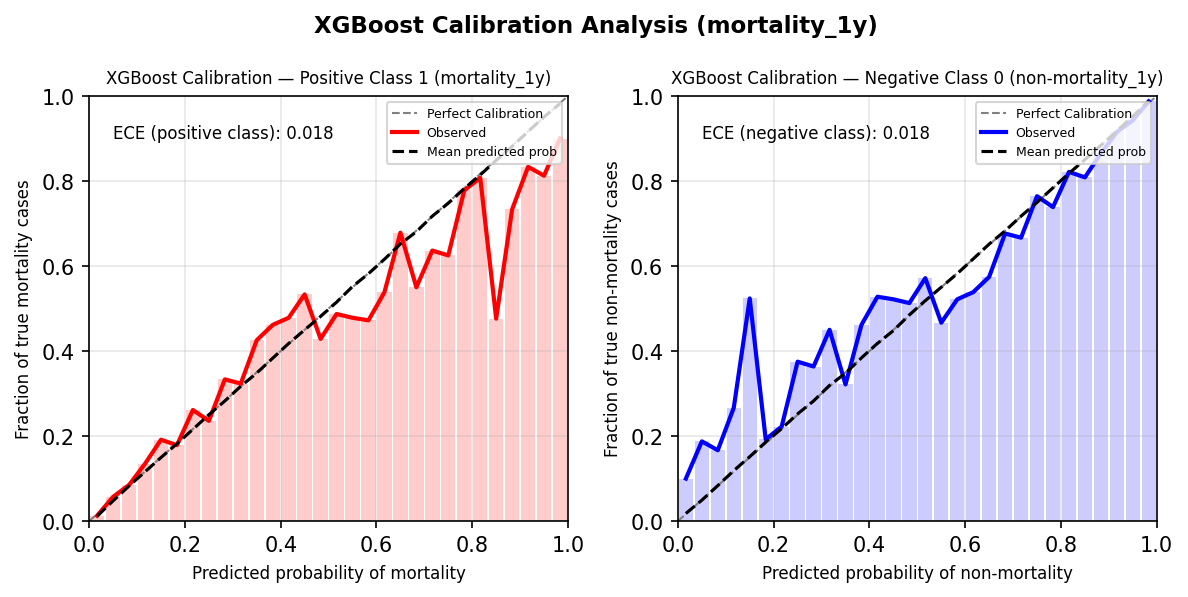

In [121]:
# ============================================================
# Calibration Analysis for XGBoost - both classes
# ============================================================
print("\n" + "="*70)
print("XGBoost Calibration Analysis (Positive and Negative classes)")
print("="*70)

# XGBoost data already computed from the main code
xgb_prob = test_prob_icu_xgb.copy()
xgb_true = test_true_icu_xbg.copy()

# Remove NaNs
mask_valid   = ~np.isnan(xgb_prob) & ~np.isnan(xgb_true.astype(float))
xgb_prob     = xgb_prob[mask_valid]
xgb_true     = xgb_true[mask_valid].astype(int)

print(f"Total test samples : {len(xgb_true)}")
print(f"Positive (label=1) : {xgb_true.sum()}")
print(f"Negative (label=0) : {(xgb_true == 0).sum()}")

# ============================================================
# ECE function
# ============================================================
def compute_ece_by_class(y_true, y_prob, target_class=1, n_bins=30):
    y_prob = y_prob.copy()
    y_true = y_true.copy()

    if target_class == 0:
        y_prob = 1 - y_prob
        y_true = (y_true == 0).astype(int)
    else:
        y_true = (y_true == 1).astype(int)

    bins         = np.linspace(0, 1, n_bins + 1)
    bin_frac_pos = []
    bin_conf     = []
    bin_sizes    = []
    ece          = 0.0
    n            = len(y_true)

    for i in range(n_bins):
        left, right = bins[i], bins[i + 1]
        bin_mask    = (y_prob >= left) & (y_prob <= right) if i == n_bins - 1 \
                      else (y_prob >= left) & (y_prob < right)
        size        = np.sum(bin_mask)

        if size == 0:
            bin_frac_pos.append(np.nan)
            bin_conf.append(np.nan)
            bin_sizes.append(0)
            continue

        frac_pos = np.sum(y_true[bin_mask] == 1) / size
        conf     = np.mean(y_prob[bin_mask])
        ece     += (size / n) * abs(frac_pos - conf)

        bin_frac_pos.append(frac_pos)
        bin_conf.append(conf)
        bin_sizes.append(size)

    return ece, bins, np.array(bin_frac_pos), np.array(bin_conf), np.array(bin_sizes)

# ============================================================
# Compute bins for both classes
# ============================================================
n_bins    = 30
bin_width = 1.0 / n_bins

xgb_ece_pos, xgb_bins_1, xgb_frac_1, xgb_conf_1, xgb_sizes_1 = compute_ece_by_class(
    xgb_true, xgb_prob, target_class=1, n_bins=n_bins)

xgb_ece_neg, xgb_bins_0, xgb_frac_0, xgb_conf_0, xgb_sizes_0 = compute_ece_by_class(
    xgb_true, xgb_prob, target_class=0, n_bins=n_bins)

xgb_centers_1 = (xgb_bins_1[:-1] + xgb_bins_1[1:]) / 2
xgb_centers_0 = (xgb_bins_0[:-1] + xgb_bins_0[1:]) / 2

xgb_brier_pos = brier_score_loss(xgb_true,       xgb_prob)
xgb_brier_neg = brier_score_loss(1 - xgb_true,   1 - xgb_prob)

print(f"\nExpected Calibration Error (ECE):")
print(f"  Positive class (label=1) ECE : {xgb_ece_pos:.4f}")
print(f"  Negative class (label=0) ECE : {xgb_ece_neg:.4f}")
print(f"\nBrier Score:")
print(f"  Positive class (label=1) : {xgb_brier_pos:.4f}")
print(f"  Negative class (label=0) : {xgb_brier_neg:.4f}")

# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# ------------------------------------------------------------
# Positive class (label=1)
# ------------------------------------------------------------
axes[0].plot([0, 1], [0, 1], '--', color='gray', linewidth=1,
             label='Perfect Calibration')
axes[0].plot(xgb_centers_1, xgb_frac_1, color='red', linewidth=2,
             label='Observed')
axes[0].plot(xgb_centers_1, xgb_conf_1, color='black', linestyle='--',
             label='Mean predicted prob')
axes[0].bar(xgb_centers_1, xgb_frac_1, width=bin_width * 0.9,
            alpha=0.2, color='red')
axes[0].text(0.05, 0.90, f"ECE (positive class): {xgb_ece_pos:.3f}",
             transform=axes[0].transAxes, fontsize=8)
axes[0].set_xlabel('Predicted probability of mortality', fontsize=8)
axes[0].set_ylabel('Fraction of true mortality cases', fontsize=8)
axes[0].set_title('XGBoost Calibration — Positive Class 1 (mortality_1y)', fontsize=8)
axes[0].legend(fontsize=8)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])
axes[0].grid(alpha=0.3)
axes[0].legend(loc='upper right', fontsize=6)
# ------------------------------------------------------------
# Negative class (label=0)
# ------------------------------------------------------------
axes[1].plot([0, 1], [0, 1], '--', color='gray', linewidth=1,
             label='Perfect Calibration')
axes[1].plot(xgb_centers_0, xgb_frac_0, color='blue', linewidth=2,
             label='Observed')
axes[1].plot(xgb_centers_0, xgb_conf_0, color='black', linestyle='--',
             label='Mean predicted prob')
axes[1].bar(xgb_centers_0, xgb_frac_0, width=bin_width * 0.9,
            alpha=0.2, color='blue')
axes[1].text(0.05, 0.90, f"ECE (negative class): {xgb_ece_neg:.3f}",
             transform=axes[1].transAxes, fontsize=8)
axes[1].set_xlabel('Predicted probability of non-mortality', fontsize=8)
axes[1].set_ylabel('Fraction of true non-mortality cases', fontsize=8)
axes[1].set_title('XGBoost Calibration — Negative Class 0 (non-mortality_1y)', fontsize=8)
axes[1].legend(fontsize=8)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])
axes[1].grid(alpha=0.3)
axes[1].legend(loc='upper right', fontsize=6)
plt.suptitle('XGBoost Calibration Analysis (mortality_1y)',
             fontsize=11, fontweight='bold')
plt.tight_layout()

# Force inline display
buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=150, bbox_inches='tight')
buf.seek(0)
display(Image.open(buf))
plt.savefig(os.path.join(PNG_DIR, "calibration_xgboost.png"),
            dpi=150, bbox_inches='tight')
plt.close()

# Deep Ensembles

In [122]:
import os
DATA_PATH=r"C:\Users\Taki Djebbar\Documents\Data Science S1\Medical Data Analysis with Deep Learning\Other\mds_ed.csv"
BASE_DIR    = r"C:\user\gaad2403\MDS-ED\key\Final\DeepEnsemble"
RESULTS_DIR = os.path.join(BASE_DIR, "results")
CSV_DIR     = os.path.join(RESULTS_DIR, "csv")
PNG_DIR     = os.path.join(RESULTS_DIR, "png")

os.makedirs(CSV_DIR, exist_ok=True)
os.makedirs(PNG_DIR, exist_ok=True)

PROB_THRESHOLDS = np.round(np.arange(0.05, 0.21, 0.01), 2)
Q_THRESHOLDS    = np.round(np.arange(0.00, 1.01, 0.01), 2)
BATCH_SIZE      = 32
LIN_FTRS        = [128, 128, 128]
M               = 5
EPSILON         = 1e-10
TARGET_TASK     = "mortality_365d"     # <-- must match training script
DEVICE          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"prob_threshold sweep: {PROB_THRESHOLDS}")
print(f"Device: {DEVICE}")

# ============================================================
# Model definitions (unchanged)
# ============================================================
class BasicEncoderStatic(EncoderStaticBase):
    def __init__(self, hparams_encoder_static, hparams_input_shape, target_dim=None):
        super().__init__(hparams_encoder_static, hparams_input_shape, target_dim)
        self.input_channels_cat  = hparams_input_shape.static_dim_cat
        self.input_channels_cont = hparams_input_shape.static_dim
        assert(len(hparams_encoder_static.embedding_dims) == hparams_input_shape.static_dim_cat
               and len(hparams_encoder_static.vocab_sizes) == hparams_input_shape.static_dim_cat)
        self.embeddings = nn.ModuleList()
        for v, e in zip(hparams_encoder_static.vocab_sizes, hparams_encoder_static.embedding_dims):
            self.embeddings.append(nn.Embedding(v, e))
        self.input_dim = int(np.sum(hparams_encoder_static.embedding_dims) + hparams_input_shape.static_dim)

    def embed(self, **kwargs):
        static     = kwargs.get("static", None)
        static_cat = kwargs.get("static_cat", None)
        res = []
        if static_cat is not None:
            for i, e in enumerate(self.embeddings):
                res.append(e(static_cat[:, i].long()))
            res = torch.cat([torch.cat(res, dim=1), static], dim=1) if static is not None else torch.cat(res, dim=1)
        else:
            res = static
        return res

    def forward(self, **kwargs): raise NotImplementedError
    def get_output_shape(self):  raise NotImplementedError


class BasicEncoderStaticMLP(BasicEncoderStatic):
    def __init__(self, hparams_encoder_static, hparams_input_shape, target_dim=None):
        super().__init__(hparams_encoder_static, hparams_input_shape, target_dim)
        lin_ftrs = [self.input_dim] + list(hparams_encoder_static.lin_ftrs)
        if target_dim is not None and lin_ftrs[-1] != target_dim:
            lin_ftrs.append(target_dim)
        ps = ([hparams_encoder_static.dropout]
              if not isinstance(hparams_encoder_static.dropout, Iterable)
              else hparams_encoder_static.dropout)
        if len(ps) == 1:
            ps = [ps[0] / 2] * (len(lin_ftrs) - 2) + ps
        actns  = [nn.ReLU(inplace=True)] * (len(lin_ftrs) - 2) + [None]
        layers = []
        for ni, no, p, actn in zip(lin_ftrs[:-1], lin_ftrs[1:], ps, actns):
            layers += bn_drop_lin(ni, no, hparams_encoder_static.batch_norm, p, actn, layer_norm=False)
        self.layers = nn.Sequential(*layers)
        self.output_shape = dataclasses.replace(hparams_input_shape)
        self.output_shape.static_dim     = int(lin_ftrs[-1])
        self.output_shape.static_dim_cat = 0

    def forward(self, **kwargs):
        return {"static": self.layers(self.embed(**kwargs))}

    def get_output_shape(self):
        return self.output_shape


@dataclass
class MLPConfig:
    embedding_dims: List[int] = field(default_factory=list)
    vocab_sizes: List[int]    = field(default_factory=list)
    lin_ftrs: List[int]       = field(default_factory=lambda: [128, 128, 128])
    dropout: float   = 0.5
    batch_norm: bool = True

@dataclass
class ShapeCfg:
    static_dim: int     = 0
    static_dim_cat: int = 0
    channels: int       = 0
    length: int         = 0
    sequence_last: bool = False
    channels2: int      = 0

# ============================================================
# 1. Load & preprocess data — IDENTICAL to training script
# ============================================================
print("\nLoading data...")
df = pd.read_csv(DATA_PATH
                 , low_memory=False)

input_cols = [c for c in df.columns if c.split("_")[0] in ['biometrics','demographics','labvalues','vitals']]

# --- missingness masks (this is what training used and this script was missing) ---
mask_columns = []
for c in input_cols:
    mask_col = c + '_m'
    df[mask_col] = df[c].notna().astype(float)
    mask_columns.append(mask_col)

df_train      = df[df['general_strat_fold'] < 18]
train_medians = df_train[input_cols].median().to_dict()
train_nans    = [c for c, v in df_train[input_cols].isna().sum().to_dict().items() if v > 0]
for c in train_nans:
    df.loc[df[c].isna(), c] = train_medians[c]
df = df.copy()

unique_counts = {c: len(np.unique(np.array(df[c]))) for c in input_cols}
cat_features  = [c for c, v in unique_counts.items()
                 if v < 10 and not c.endswith("nan") and not c.startswith("labvalues")]
cont_features = [c for c in input_cols if c not in cat_features]
cont_features = cont_features + mask_columns   # <-- masks appended, same as training

df["vitals_acuity"] = df["vitals_acuity"].apply(lambda x: int(x) - 1)

lbl_eth = ['demographics_ethnicity_asian','demographics_ethnicity_black/african',
           'demographics_ethnicity_hispanic/latino','demographics_ethnicity_other',
           'demographics_ethnicity_white']
df["demographics_ethnicity"] = df.apply(lambda r: np.where([r[c] for c in lbl_eth])[0][0], axis=1)
df.drop(lbl_eth, axis=1, inplace=True)

# --- drop the ethnicity mask columns, same as training ---
ethnicity_masks = [c + '_m' for c in lbl_eth if (c + '_m') in df.columns]
if ethnicity_masks:
    df.drop(ethnicity_masks, axis=1, inplace=True)
    mask_columns = [c for c in mask_columns if c not in ethnicity_masks]

input_cols    = [c for c in df.columns if c.split("_")[0] in ['biometrics','demographics','labvalues','vitals']]
cat_features  = [c for c in input_cols if c in cat_features]
cont_features = [c for c in input_cols if c not in cat_features]

df["deterioration_" + TARGET_TASK] = df["deterioration_" + TARGET_TASK].replace(-999., np.nan)

val_df  = df[df['general_strat_fold'] == 18].reset_index(drop=True)
test_df = df[df['general_strat_fold'] == 19].reset_index(drop=True)
val_df  = val_df[val_df['general_ecg_no_within_stay'] == 0].reset_index(drop=True)
test_df = test_df[test_df['general_ecg_no_within_stay'] == 0].reset_index(drop=True)
print(f"Val: {len(val_df)}, Test: {len(test_df)}")

# ============================================================
# 2. Dataset & DataLoader — single target task, matches training
# ============================================================
class TabularDataset(Dataset):
    def __init__(self, df, cont_features, cat_features, target_task):
        self.cont   = torch.tensor(df[cont_features].values, dtype=torch.float32)
        self.cat    = torch.tensor(df[cat_features].values,  dtype=torch.long)
        self.labels = torch.tensor(df[["deterioration_" + target_task]].values, dtype=torch.float32)
    def __len__(self): return len(self.cont)
    def __getitem__(self, idx): return self.cont[idx], self.cat[idx], self.labels[idx]

val_loader  = DataLoader(TabularDataset(val_df,  cont_features, cat_features, TARGET_TASK),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(TabularDataset(test_df, cont_features, cat_features, TARGET_TASK),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ============================================================
# 3. Load ensemble members & inference
# ============================================================
shape   = ShapeCfg(static_dim=len(cont_features), static_dim_cat=len(cat_features))
mlp_cfg = MLPConfig(
    embedding_dims=[unique_counts[c] for c in cat_features],
    vocab_sizes=[unique_counts[c] for c in cat_features],
    lin_ftrs=LIN_FTRS
)

print(f"\nLoading {M} ensemble members...")
ensemble_models = []
for m in range(M):
    pt_path = os.path.join(BASE_DIR, f"ensemble_member_{m}_mortality365d_only_mask.pt")
    model   = BasicEncoderStaticMLP(mlp_cfg, shape, target_dim=1).to(DEVICE)   # <-- target_dim=1, matches training
    model.load_state_dict(torch.load(pt_path, map_location=DEVICE, weights_only=False))
    model.eval()
    ensemble_models.append(model)
    print(f"  Loaded: {pt_path}")


def ensemble_predict(models, loader):
    all_preds_per_model = []
    for model in models:
        model.eval()
        preds = []
        with torch.no_grad():
            for cont, cat, _ in loader:
                cont, cat = cont.to(DEVICE), cat.to(DEVICE)
                probs = torch.sigmoid(model(static=cont, static_cat=cat)["static"]).cpu().numpy()
                preds.append(probs)
        all_preds_per_model.append(np.concatenate(preds, axis=0))

    all_labels = []
    for _, _, labels in loader:
        all_labels.append(labels.numpy())
    all_labels = np.concatenate(all_labels, axis=0)

    stacked   = np.stack(all_preds_per_model, axis=0)
    mean_pred = stacked.mean(axis=0)   # shape (N, 1)
    variance  = stacked.var(axis=0)
    spread    = stacked.max(axis=0) - stacked.min(axis=0)
    p         = mean_pred
    entropy   = -(p * np.log(p + EPSILON) + (1-p) * np.log(1-p + EPSILON))

    return mean_pred, variance, entropy, spread, all_labels


print("Running ensemble inference...")
print("  Val set...")
val_mean,  val_var,  val_ent,  val_spr,  val_labels  = ensemble_predict(ensemble_models, val_loader)
print("  Test set...")
test_mean, test_var, test_ent, test_spr, test_labels = ensemble_predict(ensemble_models, test_loader)
print("  Done.")

# mean_pred has shape (N, 1) since the model is single-task (mortality only)
test_prob_mortality365d = test_mean[:, 0]
print(f"\nTest set probabilities (mortality 365d) per sample:")
print(f"  Shape : {test_prob_mortality365d.shape}")
print(f"  Min   : {test_prob_mortality365d.min():.4f}")
print(f"  Max   : {test_prob_mortality365d.max():.4f}")
print(f"  Mean  : {test_prob_mortality365d.mean():.4f}")

prob_threshold sweep: [0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13 0.14 0.15 0.16 0.17 0.18
 0.19 0.2 ]
Device: cpu

Loading data...
Val: 5824, Test: 6080

Loading 5 ensemble members...
  Loaded: C:\user\gaad2403\MDS-ED\key\Final\DeepEnsemble\ensemble_member_0_mortality365d_only_mask.pt
  Loaded: C:\user\gaad2403\MDS-ED\key\Final\DeepEnsemble\ensemble_member_1_mortality365d_only_mask.pt
  Loaded: C:\user\gaad2403\MDS-ED\key\Final\DeepEnsemble\ensemble_member_2_mortality365d_only_mask.pt
  Loaded: C:\user\gaad2403\MDS-ED\key\Final\DeepEnsemble\ensemble_member_3_mortality365d_only_mask.pt
  Loaded: C:\user\gaad2403\MDS-ED\key\Final\DeepEnsemble\ensemble_member_4_mortality365d_only_mask.pt
Running ensemble inference...
  Val set...
  Test set...
  Done.

Test set probabilities (mortality 365d) per sample:
  Shape : (6080,)
  Min   : 0.0013
  Max   : 0.9726
  Mean  : 0.1277


## Deep Ensembles for ICU_24h

In [ ]:
####### used seperate section as the five saved models deom deep ensembles are diffrent #######


ICU24H_IDX=1
TARGET_TASK='icu_24h'

# ============================================================
# Model definitions (unchanged)
# ============================================================
class BasicEncoderStatic(EncoderStaticBase):
    def __init__(self, hparams_encoder_static, hparams_input_shape, target_dim=None):
        super().__init__(hparams_encoder_static, hparams_input_shape, target_dim)
        self.input_channels_cat  = hparams_input_shape.static_dim_cat
        self.input_channels_cont = hparams_input_shape.static_dim
        assert(len(hparams_encoder_static.embedding_dims) == hparams_input_shape.static_dim_cat
               and len(hparams_encoder_static.vocab_sizes) == hparams_input_shape.static_dim_cat)
        self.embeddings = nn.ModuleList()
        for v, e in zip(hparams_encoder_static.vocab_sizes, hparams_encoder_static.embedding_dims):
            self.embeddings.append(nn.Embedding(v, e))
        self.input_dim = int(np.sum(hparams_encoder_static.embedding_dims) + hparams_input_shape.static_dim)

    def embed(self, **kwargs):
        static     = kwargs.get("static", None)
        static_cat = kwargs.get("static_cat", None)
        res = []
        if static_cat is not None:
            for i, e in enumerate(self.embeddings):
                res.append(e(static_cat[:, i].long()))
            res = torch.cat([torch.cat(res, dim=1), static], dim=1) if static is not None else torch.cat(res, dim=1)
        else:
            res = static
        return res

    def forward(self, **kwargs): raise NotImplementedError
    def get_output_shape(self):  raise NotImplementedError


class BasicEncoderStaticMLP(BasicEncoderStatic):
    def __init__(self, hparams_encoder_static, hparams_input_shape, target_dim=None):
        super().__init__(hparams_encoder_static, hparams_input_shape, target_dim)
        lin_ftrs = [self.input_dim] + list(hparams_encoder_static.lin_ftrs)
        if target_dim is not None and lin_ftrs[-1] != target_dim:
            lin_ftrs.append(target_dim)
        ps = ([hparams_encoder_static.dropout]
              if not isinstance(hparams_encoder_static.dropout, Iterable)
              else hparams_encoder_static.dropout)
        if len(ps) == 1:
            ps = [ps[0] / 2] * (len(lin_ftrs) - 2) + ps
        actns  = [nn.ReLU(inplace=True)] * (len(lin_ftrs) - 2) + [None]
        layers = []
        for ni, no, p, actn in zip(lin_ftrs[:-1], lin_ftrs[1:], ps, actns):
            layers += bn_drop_lin(ni, no, hparams_encoder_static.batch_norm, p, actn, layer_norm=False)
        self.layers = nn.Sequential(*layers)
        self.output_shape = dataclasses.replace(hparams_input_shape)
        self.output_shape.static_dim     = int(lin_ftrs[-1])
        self.output_shape.static_dim_cat = 0

    def forward(self, **kwargs):
        return {"static": self.layers(self.embed(**kwargs))}

    def get_output_shape(self):
        return self.output_shape


@dataclass
class MLPConfig:
    embedding_dims: List[int] = field(default_factory=list)
    vocab_sizes: List[int]    = field(default_factory=list)
    lin_ftrs: List[int]       = field(default_factory=lambda: [128, 128, 128])
    dropout: float   = 0.5
    batch_norm: bool = True

@dataclass
class ShapeCfg:
    static_dim: int     = 0
    static_dim_cat: int = 0
    channels: int       = 0
    length: int         = 0
    sequence_last: bool = False
    channels2: int      = 0

# ============================================================
# 1. Load & preprocess data — IDENTICAL to training script
# ============================================================
print("Loading data...")
df = pd.read_csv(r'C:\Users\Taki Djebbar\Documents\Data Science S1\Medical Data Analysis with Deep Learning\Other\mds_ed.csv',
                 low_memory=False)
print(f"shape: {df.shape}")
input_cols = [c for c in df.columns if c.split("_")[0] in ['biometrics','demographics','labvalues','vitals']]

# median imputation based on training set
df_train = df[df['general_strat_fold'] < 18]
train_medians = df_train[input_cols].median().to_dict()
train_nans = [c for c,v in df_train[input_cols].isna().sum().to_dict().items() if v > 0]
for c in train_nans:
    df.loc[df[c].isna(), c] = train_medians[c]
df = df.copy()
# categorical vs continuous feature split (same as multimodal.py)
unique_counts = {c: len(np.unique(np.array(df[c]))) for c in input_cols}
cat_features = [c for c,v in unique_counts.items() if v < 10 and not c.endswith("nan") and not c.startswith("labvalues")]
cat_features_dim = [unique_counts[c] for c in cat_features]
cont_features = [c for c in input_cols if c not in cat_features]

print(f"categorical features: {len(cat_features)} dimensions: {cat_features_dim} continuous features: {len(cont_features)}")

# vitals_acuity: convert from 1-based to 0-based indexing
df["vitals_acuity"] = df["vitals_acuity"].apply(lambda x: int(x)-1)

# ethnicity → categorical encoding (same as multimodal.py)
lbl_itos_ethnicity = [
    'demographics_ethnicity_asian',
    'demographics_ethnicity_black/african',
    'demographics_ethnicity_hispanic/latino',
    'demographics_ethnicity_other',
    'demographics_ethnicity_white'
]

df["demographics_ethnicity"] = df.apply(
    lambda row: np.where([row[c] for c in lbl_itos_ethnicity])[0][0], axis=1
)
df.drop(lbl_itos_ethnicity, axis=1, inplace=True)
input_cols = [c for c in df.columns if c.split("_")[0] in ['biometrics','demographics','labvalues','vitals']]
cat_features = [c for c in cat_features if c in df.columns]
cat_features = [c for c in input_cols if c in cat_features]
cont_features = [c for c in input_cols if c not in cat_features]

# deterioration labels
lbl_itos_deterioration = ["mortality_365d","icu_24h","cardiac_arrest","vasopressors"]
for c in lbl_itos_deterioration:
    df["deterioration_"+c] = df["deterioration_"+c].replace(-999., np.nan)
target_cols = [
    "deterioration_mortality_365d",
    "deterioration_icu_24h",
    "deterioration_icu_24h",
    "deterioration_vasopressors"
]# 3. Train / Validation / Test split
# ----------------------------------------
train_df = df[df['general_strat_fold'].isin(range(0, 18))].reset_index(drop=True)
val_df   = df[df['general_strat_fold'] == 18].reset_index(drop=True)
test_df  = df[df['general_strat_fold'] == 19].reset_index(drop=True)
# only first ECG per hospital stay for validation/test
val_df   = val_df[val_df['general_ecg_no_within_stay'] == 0].reset_index(drop=True)
test_df  = test_df[test_df['general_ecg_no_within_stay'] == 0].reset_index(drop=True)

print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")
# ============================================================
# 2. Dataset & DataLoader — single target task, matches training
# ============================================================
class TabularDataset(Dataset):
    def __init__(self, df, cont_features, cat_features, target_task):
        self.cont   = torch.tensor(df[cont_features].values, dtype=torch.float32)
        self.cat    = torch.tensor(df[cat_features].values,  dtype=torch.long)
        self.labels = torch.tensor(df[["deterioration_" + target_task]].values, dtype=torch.float32)
    def __len__(self): return len(self.cont)
    def __getitem__(self, idx): return self.cont[idx], self.cat[idx], self.labels[idx]

val_loader  = DataLoader(TabularDataset(val_df,  cont_features, cat_features, TARGET_TASK),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(TabularDataset(test_df, cont_features, cat_features, TARGET_TASK),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ============================================================
# 3. Load ensemble members & inference
# ============================================================
shape   = ShapeCfg(static_dim=len(cont_features), static_dim_cat=len(cat_features))
mlp_cfg = MLPConfig(
    embedding_dims=[unique_counts[c] for c in cat_features],
    vocab_sizes=[unique_counts[c] for c in cat_features],
    lin_ftrs=LIN_FTRS
)

print(f"\nLoading {M} ensemble members...")
ensemble_models = []
for m in range(M):
    pt_path = os.path.join(BASE_DIR, f"ensemble_model_{m}.pt")
    model   = BasicEncoderStaticMLP(mlp_cfg, shape, target_dim=4).to(DEVICE)   # <-- target_dim=1, matches training
    model.load_state_dict(torch.load(pt_path, map_location=DEVICE, weights_only=False))
    model.eval()
    ensemble_models.append(model)
    print(f"  Loaded: {pt_path}")


def ensemble_predict(models, loader):
    all_preds_per_model = []
    for model in models:
        model.eval()
        preds = []
        with torch.no_grad():
            for cont, cat, _ in loader:
                cont, cat = cont.to(DEVICE), cat.to(DEVICE)
                probs = torch.sigmoid(model(static=cont, static_cat=cat)["static"]).cpu().numpy()
                preds.append(probs)
        all_preds_per_model.append(np.concatenate(preds, axis=0))

    all_labels = []
    for _, _, labels in loader:
        all_labels.append(labels.numpy())
    all_labels = np.concatenate(all_labels, axis=0)

    stacked   = np.stack(all_preds_per_model, axis=0)
    mean_pred = stacked.mean(axis=0)   # shape (N, 1)
    variance  = stacked.var(axis=0)
    spread    = stacked.max(axis=0) - stacked.min(axis=0)
    p         = mean_pred
    entropy   = -(p * np.log(p + EPSILON) + (1-p) * np.log(1-p + EPSILON))

    return mean_pred, variance, entropy, spread, all_labels


print("Running ensemble inference...")
print("  Val set...")
val_mean,  val_var,  val_ent,  val_spr,  val_labels  = ensemble_predict(ensemble_models, val_loader)
print("  Test set...")
test_mean, test_var, test_ent, test_spr, test_labels = ensemble_predict(ensemble_models, test_loader)
print("  Done.")
test_prob_icu_dp = test_mean[:, 1]


Loading data...
shape: (129057, 1936)
categorical features: 7 dimensions: [2, 2, 2, 2, 2, 2, 5] continuous features: 463
Train: 116433, Validation: 5824, Test: 6080

Loading 5 ensemble members...
  Loaded: C:\user\gaad2403\MDS-ED\key\Final\DeepEnsemble\ensemble_model_0.pt
  Loaded: C:\user\gaad2403\MDS-ED\key\Final\DeepEnsemble\ensemble_model_1.pt
  Loaded: C:\user\gaad2403\MDS-ED\key\Final\DeepEnsemble\ensemble_model_2.pt
  Loaded: C:\user\gaad2403\MDS-ED\key\Final\DeepEnsemble\ensemble_model_3.pt
  Loaded: C:\user\gaad2403\MDS-ED\key\Final\DeepEnsemble\ensemble_model_4.pt
Running ensemble inference...
  Val set...
  Test set...
  Done.



Calibration Analysis (Positive and Negative classes)
Total test samples : 6069
Positive (label=1) : 835
Negative (label=0) : 5234

Expected Calibration Error (ECE):
  Positive class (label=1) ECE : 0.0260
  Negative class (label=0) ECE : 0.0259

Brier Score:
  Positive class (label=1) : 0.0877
  Negative class (label=0) : 0.0877


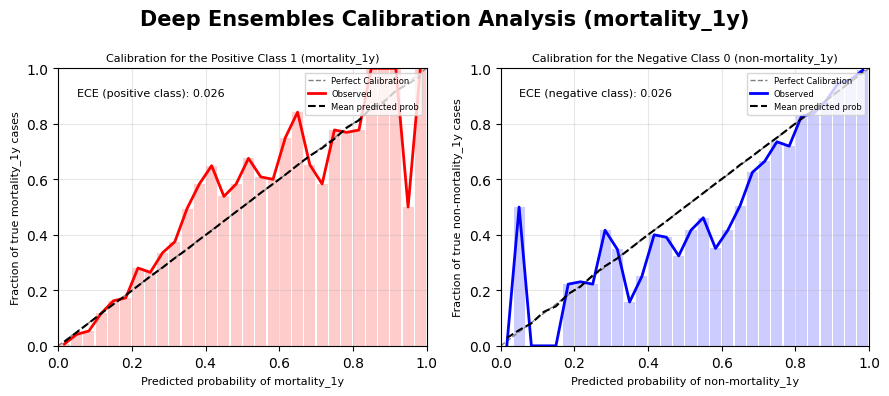

In [133]:
# ============================================================
# Calibration Analysis for both classes
# ============================================================
print("\n" + "="*70)
print("Calibration Analysis (Positive and Negative classes)")
print("="*70)
ICU24H_IDX=0
# Apply mask to get only valid (non-NaN) samples
test_labels_flat = test_labels.ravel()          # force to (N,)
test_probs_col    = test_mean[:, ICU24H_IDX]  # already (N,)

test_mask = ~np.isnan(test_labels_flat)

test_prob_icu_deep_ensembles = test_probs_col[test_mask]
test_true_icu_deep_ensembles = test_labels_flat[test_mask].astype(int)

print(f"Total test samples : {len(test_true_icu_deep_ensembles)}")
print(f"Positive (label=1) : {test_true_icu_deep_ensembles.sum()}")
print(f"Negative (label=0) : {(test_true_icu_deep_ensembles == 0).sum()}")

# ECE function
def compute_ece(true_labels, pred_probs, n_bins=30):
    bins  = np.linspace(0.0, 1.0, n_bins + 1)
    ece   = 0.0
    total = len(pred_probs)
    for i in range(n_bins):
        mask      = (pred_probs >= bins[i]) & (pred_probs < bins[i+1])
        bin_count = mask.sum()
        if bin_count == 0:
            continue
        ece += (bin_count / total) * abs(true_labels[mask].mean() - pred_probs[mask].mean())
    return ece

# ============================================================
# Compute bins manually for both classes
# ============================================================
n_bins    = 30
bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
bin_width = bin_edges[1] - bin_edges[0]
centers   = (bin_edges[:-1] + bin_edges[1:]) / 2

# --- Positive class ---
frac_pos_DE = np.full(n_bins, np.nan)
conf_pos     = np.full(n_bins, np.nan)
for i in range(n_bins):
    mask = (test_prob_icu_deep_ensembles >= bin_edges[i]) & (test_prob_icu_deep_ensembles < bin_edges[i+1])
    if mask.sum() > 0:
        frac_pos_DE[i] = test_true_icu_deep_ensembles[mask].mean()
        conf_pos[i]     = test_prob_icu_deep_ensembles[mask].mean()

# --- Negative class ---
neg_probs    = 1 - test_prob_icu_deep_ensembles
neg_true     = 1 - test_true_icu_deep_ensembles
frac_neg_DE = np.full(n_bins, np.nan)
conf_neg     = np.full(n_bins, np.nan)
for i in range(n_bins):
    mask = (neg_probs >= bin_edges[i]) & (neg_probs < bin_edges[i+1])
    if mask.sum() > 0:
        frac_neg_DE[i] = neg_true[mask].mean()
        conf_neg[i]     = neg_probs[mask].mean()

ece_pos_DE = compute_ece(test_true_icu_deep_ensembles, test_prob_icu_deep_ensembles,   n_bins=30)
ece_neg_DE = compute_ece(neg_true,      neg_probs,        n_bins=30)

brier_pos = brier_score_loss(test_true_icu_deep_ensembles, test_prob_icu_deep_ensembles)
brier_neg = brier_score_loss(neg_true,      neg_probs)

print(f"\nExpected Calibration Error (ECE):")
print(f"  Positive class (label=1) ECE : {ece_pos_DE:.4f}")
print(f"  Negative class (label=0) ECE : {ece_neg_DE:.4f}")
print(f"\nBrier Score:")
print(f"  Positive class (label=1) : {brier_pos:.4f}")
print(f"  Negative class (label=0) : {brier_neg:.4f}")

# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# ------------------------------------------------------------
# Positive class
# ------------------------------------------------------------
axes[0].plot([0, 1], [0, 1], '--', color='gray', linewidth=1,
             label='Perfect Calibration')
axes[0].plot(centers, frac_pos_DE, color='red', linewidth=2,
             label='Observed')
axes[0].plot(centers, conf_pos, color='black', linestyle='--',
             label='Mean predicted prob')
axes[0].bar(centers, frac_pos_DE, width=bin_width * 0.9,
            alpha=0.2, color='red')
axes[0].text(0.05, 0.90, f"ECE (positive class): {ece_pos_DE:.3f}",
             transform=axes[0].transAxes, fontsize=8)
axes[0].set_xlabel('Predicted probability of mortality_1y', fontsize=8)
axes[0].set_ylabel('Fraction of true mortality_1y cases', fontsize=8)
axes[0].set_title('Calibration for the Positive Class 1 (mortality_1y)', fontsize=8)
axes[0].legend(loc='upper right', fontsize=6)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])
axes[0].grid(alpha=0.3)

# ------------------------------------------------------------
# Negative class
# ------------------------------------------------------------
axes[1].plot([0, 1], [0, 1], '--', color='gray', linewidth=1,
             label='Perfect Calibration')
axes[1].plot(centers, frac_neg_DE, color='blue', linewidth=2,
             label='Observed')
axes[1].plot(centers, conf_neg, color='black', linestyle='--',
             label='Mean predicted prob')
axes[1].bar(centers, frac_neg_DE, width=bin_width * 0.9,
            alpha=0.2, color='blue')
axes[1].text(0.05, 0.90, f"ECE (negative class): {ece_neg_DE:.3f}",
             transform=axes[1].transAxes, fontsize=8)
axes[1].set_xlabel('Predicted probability of non-mortality_1y', fontsize=8)
axes[1].set_ylabel('Fraction of true non-mortality_1y cases', fontsize=8)
axes[1].set_title('Calibration for the Negative Class 0 (non-mortality_1y)', fontsize=8)
axes[1].legend(loc='upper right', fontsize=6)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])
axes[1].grid(alpha=0.3)

plt.suptitle('Deep Ensembles Calibration Analysis (mortality_1y)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PNG_DIR, "calibration_both_classes.png"),
            dpi=150, bbox_inches='tight')
plt.show()

# Loading the MLP Model

In [104]:
encoder = torch.load(
    "best_realmlp.pt",
    map_location="cpu",
    weights_only=False
)
encoder.eval()

BasicEncoderStaticMLP(
  (embeddings): ModuleList(
    (0): Embedding(2, 2)
    (1): Embedding(5, 5)
  )
  (layers): Sequential(
    (0): BatchNorm1d(471, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): Dropout(p=0.25, inplace=False)
    (2): Linear(in_features=471, out_features=128, bias=True)
    (3): ReLU(inplace=True)
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): Dropout(p=0.25, inplace=False)
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): ReLU(inplace=True)
    (8): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Dropout(p=0.25, inplace=False)
    (10): Linear(in_features=128, out_features=128, bias=True)
    (11): ReLU(inplace=True)
    (12): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): Dropout(p=0.5, inplace=False)
    (14): Linear(in_features=128, out_features=4, bias=True)
  )
)

# MLP Calibration diagram

In [134]:
# ----------------------------------------
# 1. Load data (same as multimodal.py)
# ----------------------------------------
print("Loading data...")
df = pd.read_csv(r'C:\Users\Taki Djebbar\Documents\Data Science S1\Medical Data Analysis with Deep Learning\Other\mds_ed.csv',
                 low_memory=False)
print(f"shape: {df.shape}")
input_cols = [c for c in df.columns if c.split("_")[0] in ['biometrics','demographics','labvalues','vitals']]

# median imputation based on training set
df_train = df[df['general_strat_fold'] < 18]
train_medians = df_train[input_cols].median().to_dict()
train_nans = [c for c,v in df_train[input_cols].isna().sum().to_dict().items() if v > 0]
for c in train_nans:
    df.loc[df[c].isna(), c] = train_medians[c]
df = df.copy()
# categorical vs continuous feature split (same as multimodal.py)
unique_counts = {c: len(np.unique(np.array(df[c]))) for c in input_cols}
cat_features = [c for c,v in unique_counts.items() if v < 10 and not c.endswith("nan") and not c.startswith("labvalues")]
cat_features_dim = [unique_counts[c] for c in cat_features]
cont_features = [c for c in input_cols if c not in cat_features]

print(f"categorical features: {len(cat_features)} dimensions: {cat_features_dim} continuous features: {len(cont_features)}")

# vitals_acuity: convert from 1-based to 0-based indexing
df["vitals_acuity"] = df["vitals_acuity"].apply(lambda x: int(x)-1)

# ethnicity → categorical encoding (same as multimodal.py)
lbl_itos_ethnicity = [
    'demographics_ethnicity_asian',
    'demographics_ethnicity_black/african',
    'demographics_ethnicity_hispanic/latino',
    'demographics_ethnicity_other',
    'demographics_ethnicity_white'
]

df["demographics_ethnicity"] = df.apply(
    lambda row: np.where([row[c] for c in lbl_itos_ethnicity])[0][0], axis=1
)
df.drop(lbl_itos_ethnicity, axis=1, inplace=True)
input_cols = [c for c in df.columns if c.split("_")[0] in ['biometrics','demographics','labvalues','vitals']]
cat_features = [c for c in cat_features if c in df.columns]
cat_features = [c for c in input_cols if c in cat_features]
cont_features = [c for c in input_cols if c not in cat_features]

# deterioration labels
lbl_itos_deterioration = ["mortality_365d","icu_24h","cardiac_arrest","vasopressors"]
for c in lbl_itos_deterioration:
    df["deterioration_"+c] = df["deterioration_"+c].replace(-999., np.nan)
target_cols = [
    "deterioration_mortality_365d",
    "deterioration_icu_24h",
    "deterioration_icu_24h",
    "deterioration_vasopressors"
]# 3. Train / Validation / Test split
# ----------------------------------------
train_df = df[df['general_strat_fold'].isin(range(0, 18))].reset_index(drop=True)
val_df   = df[df['general_strat_fold'] == 18].reset_index(drop=True)
test_df  = df[df['general_strat_fold'] == 19].reset_index(drop=True)
# only first ECG per hospital stay for validation/test
val_df   = val_df[val_df['general_ecg_no_within_stay'] == 0].reset_index(drop=True)
test_df  = test_df[test_df['general_ecg_no_within_stay'] == 0].reset_index(drop=True)

print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")
# 4. Dataset
# ----------------------------------------
class TabularDataset(Dataset):
    def __init__(self, df, cont_features, cat_features, lbl_cols):
        self.cont = torch.tensor(df[cont_features].values, dtype=torch.float32)
        self.cat  = torch.tensor(df[cat_features].values, dtype=torch.long)
        self.labels = torch.tensor(df[["deterioration_"+c for c in lbl_cols]].values, dtype=torch.float32)

    def __len__(self):
        return len(self.cont)

    def __getitem__(self, idx):
        return self.cont[idx], self.cat[idx], self.labels[idx]

train_ds = TabularDataset(train_df, cont_features, cat_features, lbl_itos_deterioration)
val_ds   = TabularDataset(val_df,   cont_features, cat_features, lbl_itos_deterioration)
test_ds  = TabularDataset(test_df,  cont_features, cat_features, lbl_itos_deterioration)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    

Loading data...
shape: (129057, 1936)
categorical features: 7 dimensions: [2, 2, 2, 2, 2, 2, 5] continuous features: 463
Train: 116433, Validation: 5824, Test: 6080


In [135]:
# ----------------------------------------
# Load the trained model
# ----------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


encoder = torch.load(
    "best_realmlp.pt",
    map_location=device,
    weights_only=False      # Needed in PyTorch >=2.6
)
encoder.eval()


# ----------------------------------------
# Predict on validation set
# ----------------------------------------
all_preds, all_labels = [], []

with torch.no_grad():

    for cont, cat, labels in val_loader:

        cont = cont.to(DEVICE)
        cat  = cat.to(DEVICE)

        out = encoder(static=cont, static_cat=cat)

        probs = torch.sigmoid(out["static"])

        all_preds.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_preds  = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)


# ----------------------------------------
# Extract mortality_365d predictions and labels
# ----------------------------------------
target_idx = 0

mask = ~np.isnan(all_labels[:, target_idx])

y_true = all_labels[:, target_idx]
y_prob = all_preds[:, target_idx]


# ----------------------------------------
# Save to CSV
# ----------------------------------------
results = pd.DataFrame({
    "Mortality_1y_true": y_true.astype(int),
    "Mortality_1y_probability": y_prob
})


print(results)


      Mortality_1y_true  Mortality_1y_probability
0                     0                  0.010083
1                     0                  0.002172
2                     0                  0.072829
3                     0                  0.132783
4                     0                  0.325137
...                 ...                       ...
5819                  0                  0.010048
5820                  0                  0.353141
5821                  0                  0.088662
5822                  0                  0.114576
5823                  0                  0.020841

[5824 rows x 2 columns]


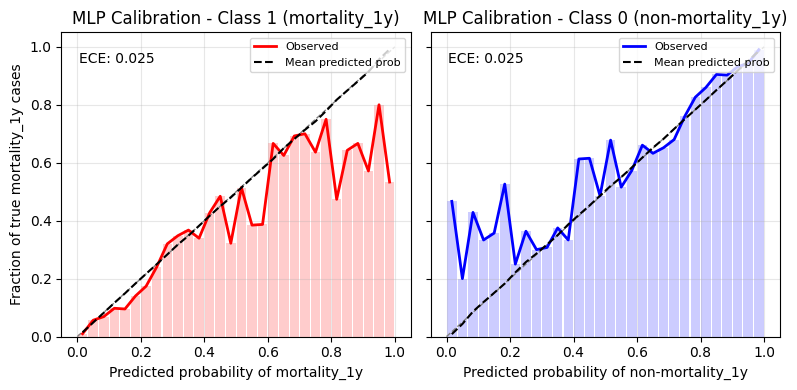

In [136]:
# =========================================================
# 1. Load from results table
# =========================================================

mask = ~np.isnan(y_true) & ~np.isnan(y_prob)
y_true = y_true[mask]
y_prob = y_prob[mask]

# =========================================================
# 2. Binning setup
# =========================================================
n_bins = 30
bins = np.linspace(0, 1, n_bins + 1)
centers = (bins[:-1] + bins[1:]) / 2
bin_width = 1.0 / n_bins

# =========================================================
# 3. Helper function (same logic as MC dropout)
# =========================================================
def calibration_stats(y_true, y_prob):
    frac_pos = []
    conf = []
    ece = 0.0
    n = len(y_true)

    for i in range(n_bins):

        left, right = bins[i], bins[i + 1]

        if i == n_bins - 1:
            mask = (y_prob >= left) & (y_prob <= right)
        else:
            mask = (y_prob >= left) & (y_prob < right)

        size = np.sum(mask)

        if size == 0:
            frac_pos.append(np.nan)
            conf.append(np.nan)
            continue

        acc = np.mean(y_true[mask])
        avg_conf = np.mean(y_prob[mask])

        frac_pos.append(acc)
        conf.append(avg_conf)

        ece += (size / n) * abs(acc - avg_conf)

    return np.array(frac_pos), np.array(conf), ece

# =========================================================
# 4. CLASS 1 (ICU = 1)
# =========================================================
frac_pos_1_mlp, conf_1, ece_1 = calibration_stats(y_true, y_prob)

# =========================================================
# 5. CLASS 0 (ICU = 0)
# =========================================================
y_true_0 = 1 - y_true
y_prob_0 = 1 - y_prob

frac_pos_0_mlp, conf_0, ece_0 = calibration_stats(y_true_0, y_prob_0)

# =========================================================
# 6. Plot CLASS 1
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

# -------------------------
# CLASS 1 (ICU = 1)
# -------------------------
axes[0].plot([0, 1], [0, 1], '--', color='gray', linewidth=1)

axes[0].bar(
    centers, frac_pos_1_mlp,
    width=bin_width * 0.9,
    alpha=0.2,
    color='red'
)

axes[0].plot(
    centers, frac_pos_1_mlp,
    color='red',
    linewidth=2,
    label="Observed"
)

axes[0].plot(
    centers, conf_1,
    color='black',
    linestyle='--',
    label="Mean predicted prob"
)

axes[0].text(
    0.05, 0.90,
    f"ECE: {ece_1:.3f}",
    transform=axes[0].transAxes
)

axes[0].set_xlabel("Predicted probability of mortality_1y")
axes[0].set_ylabel("Fraction of true mortality_1y cases")
axes[0].set_title("MLP Calibration - Class 1 (mortality_1y)")
axes[0].legend(loc='upper right',fontsize=8)
axes[0].grid(alpha=0.3)


# -------------------------
# CLASS 0 (ICU = 0)
# -------------------------
axes[1].plot([0, 1], [0, 1], '--', color='gray', linewidth=1)

axes[1].bar(
    centers, frac_pos_0_mlp,
    width=bin_width * 0.9,
    alpha=0.2,
    color='blue'
)

axes[1].plot(
    centers, frac_pos_0_mlp,
    color='blue',
    linewidth=2,
    label="Observed"
)

axes[1].plot(
    centers, conf_0,
    color='black',
    linestyle='--',
    label="Mean predicted prob"
)

axes[1].text(
    0.05, 0.90,
    f"ECE: {ece_0:.3f}",
    transform=axes[1].transAxes
)

axes[1].set_xlabel("Predicted probability of non-mortality_1y")
axes[1].set_title("MLP Calibration - Class 0 (non-mortality_1y)")
axes[1].legend(loc='upper right',fontsize=8)
axes[1].grid(alpha=0.3)


plt.tight_layout()
plt.show()

# MC Dropout

In [137]:
def mc_dropout_predict(model, test_loader, device, n_samples=50):

    model.train()  # IMPORTANT: keep dropout active

    all_mean_preds = []
    all_uncertainties = []
    all_labels = []

    with torch.no_grad():

        for cont, cat, labels in test_loader:

            cont = cont.to(device)
            cat  = cat.to(device)

            mc_samples = []

            # ----------------------------------------
            # Multiple stochastic forward passes
            # ----------------------------------------
            for _ in range(n_samples):

                out = model(static=cont, static_cat=cat)
                probs = torch.sigmoid(out["static"])

                mc_samples.append(probs.cpu().numpy())

            mc_samples = np.array(mc_samples)

            # -------------
            # 
            # ---------------------------
            # MC statistics
            # ----------------------------------------
            mean_preds = mc_samples.mean(axis=0)
            uncertainty = mc_samples.std(axis=0)

            all_mean_preds.append(mean_preds)
            all_uncertainties.append(uncertainty)
            all_labels.append(labels.numpy())

    all_mean_preds = np.concatenate(all_mean_preds, axis=0)
    all_uncertainties = np.concatenate(all_uncertainties, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    return all_mean_preds, all_uncertainties, all_labels


Running Monte Carlo Dropout...


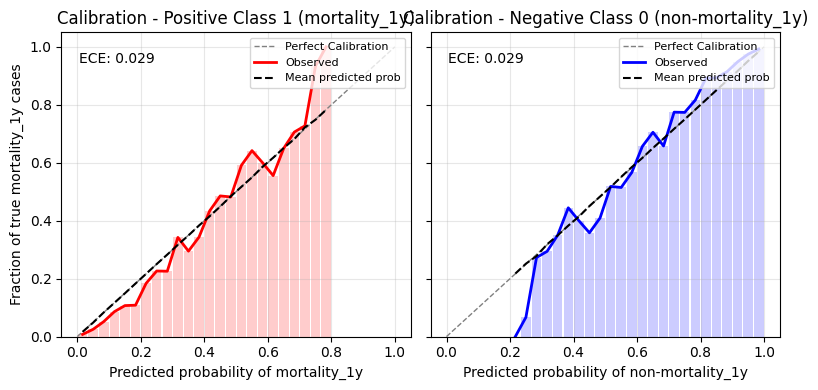

In [138]:
# =========================================================
# 1. MC Dropout prediction
# =========================================================
print("\nRunning Monte Carlo Dropout...")

all_mean_preds, all_uncertainties, y_true = mc_dropout_predict(
    encoder,
    test_loader,
    device,
    n_samples=50
)

# =========================================================
# 2. Extract ICU_24h only
# =========================================================
target_idx = 0

y_prob = all_mean_preds[:, target_idx]
y_true = y_true[:, target_idx]

mask = ~np.isnan(y_true)

y_prob_mc = y_prob[mask]
y_true_mc = y_true[mask].astype(int)

# =========================================================
# 3. Manual binning (same style as your plot)
# =========================================================
n_bins = 30
bins = np.linspace(0, 1, n_bins + 1)

frac_pos_mc = []
conf = []
bin_sizes = []

ece = 0.0
n = len(y_true_mc)

for i in range(n_bins):

    left, right = bins[i], bins[i + 1]

    if i == n_bins - 1:
        bin_mask = (y_prob_mc >= left) & (y_prob_mc <= right)
    else:
        bin_mask = (y_prob_mc >= left) & (y_prob_mc < right)

    size = np.sum(bin_mask)

    if size == 0:
        frac_pos_mc.append(np.nan)
        conf.append(np.nan)
        bin_sizes.append(0)
        continue

    acc = np.mean(y_true_mc[bin_mask])
    avg_conf = np.mean(y_prob_mc[bin_mask])

    frac_pos_mc.append(acc)
    conf.append(avg_conf)
    bin_sizes.append(size)

    ece += (size / n) * abs(acc - avg_conf)

frac_pos_mc = np.array(frac_pos_mc)
conf = np.array(conf)

centers = (bins[:-1] + bins[1:]) / 2
bin_width = 1.0 / n_bins



# =========================================================
# 5. SAME FOR NEGATIVE CLASS (ICU = 0)
# =========================================================
y_prob_neg_mc = 1 - y_prob_mc
y_true_neg_mc = 1 - y_true_mc

frac_n_mc = []
conf_n = []

ece_neg = 0.0

for i in range(n_bins):

    left, right = bins[i], bins[i + 1]

    if i == n_bins - 1:
        bin_mask = (y_prob_neg_mc >= left) & (y_prob_neg_mc <= right)
    else:
        bin_mask = (y_prob_neg_mc >= left) & (y_prob_neg_mc < right)

    size = np.sum(bin_mask)

    if size == 0:
        frac_n_mc.append(np.nan)
        conf_n.append(np.nan)
        continue

    acc = np.mean(y_true_neg_mc[bin_mask])
    avg_conf = np.mean(y_prob_neg_mc[bin_mask])

    frac_n_mc.append(acc)
    conf_n.append(avg_conf)

    ece_neg += (size / n) * abs(acc - avg_conf)

frac_n_mc = np.array(frac_n_mc)
conf_n = np.array(conf_n)
# =========================================================
# 4-6. Plot positive and negative classes as subplots
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

# =========================================================
# LEFT: Positive class (mortality_1y = 1)
# =========================================================

axes[0].plot(
    [0, 1], [0, 1],
    '--',
    color='gray',
    linewidth=1,
    label="Perfect Calibration"
)

axes[0].bar(
    centers,
    frac_pos_mc,
    width=bin_width * 0.9,
    alpha=0.2,
    color='red'
)

axes[0].plot(
    centers,
    frac_pos_mc,
    color='red',
    linewidth=2,
    label="Observed"
)

axes[0].plot(
    centers,
    conf,
    color='black',
    linestyle='--',
    label="Mean predicted prob"
)

axes[0].text(
    0.05,
    0.90,
    f"ECE: {ece:.3f}",
    transform=axes[0].transAxes
)

axes[0].set_xlabel("Predicted probability of mortality_1y")
axes[0].set_ylabel("Fraction of true mortality_1y cases")
axes[0].set_title("Calibration - Positive Class 1 (mortality_1y)")
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(alpha=0.3)


# =========================================================
# RIGHT: Negative class (mortality_1y = 0)
# =========================================================

axes[1].plot(
    [0, 1], [0, 1],
    '--',
    color='gray',
    linewidth=1,
    label="Perfect Calibration"
)

axes[1].bar(
    centers,
    frac_n_mc,
    width=bin_width * 0.9,
    alpha=0.2,
    color='blue'
)

axes[1].plot(
    centers,
    frac_n_mc,
    color='blue',
    linewidth=2,
    label="Observed"
)

axes[1].plot(
    centers,
    conf_n,
    color='black',
    linestyle='--',
    label="Mean predicted prob"
)

axes[1].text(
    0.05,
    0.90,
    f"ECE: {ece_neg:.3f}",
    transform=axes[1].transAxes
)

axes[1].set_xlabel("Predicted probability of non-mortality_1y")
axes[1].set_title("Calibration - Negative Class 0 (non-mortality_1y)")
axes[1].legend(loc='upper right',fontsize=8)
axes[1].grid(alpha=0.3)


plt.tight_layout()
plt.show()


# Combine all the methods

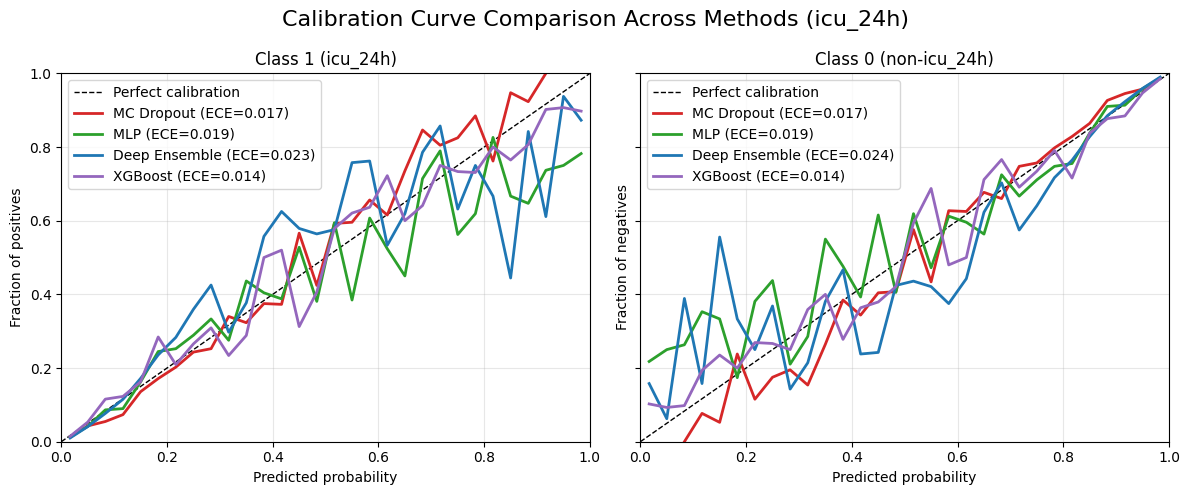

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

colors = {
    "MC Dropout": "#d62728",
    "MLP": "#2ca02c",
    "Deep Ensemble": "#1f77b4",
    "XGBoost": "#9467bd"
}

# ==========================================================
# Class 1 (ICU)
# ==========================================================
ax = axes[0]

ax.plot([0, 1], [0, 1], '--', color='black', linewidth=1,
        label='Perfect calibration')

ax.plot(
    centers,
    frac_pos_mc,
    color=colors["MC Dropout"],
    linewidth=2,
    label=f"MC Dropout (ECE={ece:.3f})"
)

ax.plot(
    centers,
    frac_pos_1_mlp,
    color=colors["MLP"],
    linewidth=2,
    label=f"MLP (ECE={ece_1:.3f})"
)

ax.plot(
    centers,
    frac_pos_DE,
    color=colors["Deep Ensemble"],
    linewidth=2,
    label=f"Deep Ensemble (ECE={ece_pos_DE:.3f})"
)

ax.plot(
    xgb_centers_1,
    xgb_frac_1,
    color=colors["XGBoost"],
    linewidth=2,
    label=f"XGBoost (ECE={xgb_ece_pos:.3f})"
)

ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Class 1 (icu_24h)")
ax.grid(alpha=0.3)
ax.legend()


# ==========================================================
# Class 0 (Non-ICU)
# ==========================================================
ax = axes[1]

ax.plot([0, 1], [0, 1], '--', color='black', linewidth=1,
        label='Perfect calibration')

ax.plot(
    centers,
    frac_n_mc,
    color=colors["MC Dropout"],
    linewidth=2,
    label=f"MC Dropout (ECE={ece_neg:.3f})"
)

ax.plot(
    centers,
    frac_pos_0_mlp,
    color=colors["MLP"],
    linewidth=2,
    label=f"MLP (ECE={ece_0:.3f})"
)

ax.plot(
    centers,
    frac_neg_DE,
    color=colors["Deep Ensemble"],
    linewidth=2,
    label=f"Deep Ensemble (ECE={ece_neg_DE:.3f})"
)

ax.plot(
    xgb_centers_0,
    xgb_frac_0,
    color=colors["XGBoost"],
    linewidth=2,
    label=f"XGBoost (ECE={xgb_ece_neg:.3f})"
)

ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Fraction of negatives")
ax.set_title("Class 0 (non-icu_24h)")
ax.grid(alpha=0.3)
ax.legend()

plt.suptitle("Calibration Curve Comparison Across Methods (icu_24h)", fontsize=16)
plt.tight_layout()
plt.show()

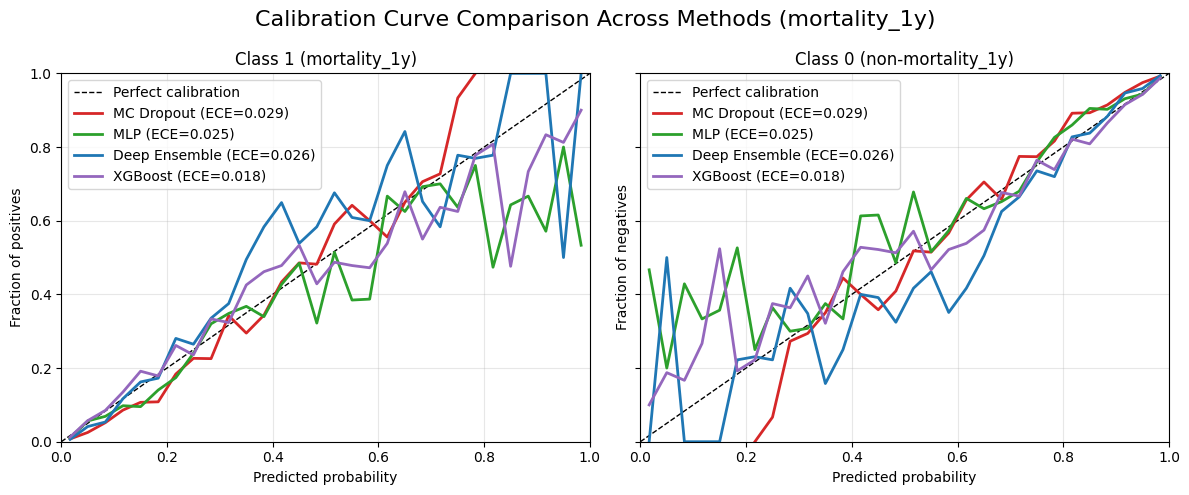

In [139]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

colors = {
    "MC Dropout": "#d62728",
    "MLP": "#2ca02c",
    "Deep Ensemble": "#1f77b4",
    "XGBoost": "#9467bd"
}

# ==========================================================
# Class 1 (ICU)
# ==========================================================
ax = axes[0]

ax.plot([0, 1], [0, 1], '--', color='black', linewidth=1,
        label='Perfect calibration')

ax.plot(
    centers,
    frac_pos_mc,
    color=colors["MC Dropout"],
    linewidth=2,
    label=f"MC Dropout (ECE={ece:.3f})"
)

ax.plot(
    centers,
    frac_pos_1_mlp,
    color=colors["MLP"],
    linewidth=2,
    label=f"MLP (ECE={ece_1:.3f})"
)

ax.plot(
    centers,
    frac_pos_DE,
    color=colors["Deep Ensemble"],
    linewidth=2,
    label=f"Deep Ensemble (ECE={ece_pos_DE:.3f})"
)

ax.plot(
    xgb_centers_1,
    xgb_frac_1,
    color=colors["XGBoost"],
    linewidth=2,
    label=f"XGBoost (ECE={xgb_ece_pos:.3f})"
)

ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Class 1 (mortality_1y)")
ax.grid(alpha=0.3)
ax.legend()


# ==========================================================
# Class 0 (Non-ICU)
# ==========================================================
ax = axes[1]

ax.plot([0, 1], [0, 1], '--', color='black', linewidth=1,
        label='Perfect calibration')

ax.plot(
    centers,
    frac_n_mc,
    color=colors["MC Dropout"],
    linewidth=2,
    label=f"MC Dropout (ECE={ece_neg:.3f})"
)

ax.plot(
    centers,
    frac_pos_0_mlp,
    color=colors["MLP"],
    linewidth=2,
    label=f"MLP (ECE={ece_0:.3f})"
)

ax.plot(
    centers,
    frac_neg_DE,
    color=colors["Deep Ensemble"],
    linewidth=2,
    label=f"Deep Ensemble (ECE={ece_neg_DE:.3f})"
)

ax.plot(
    xgb_centers_0,
    xgb_frac_0,
    color=colors["XGBoost"],
    linewidth=2,
    label=f"XGBoost (ECE={xgb_ece_neg:.3f})"
)

ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Fraction of negatives")
ax.set_title("Class 0 (non-mortality_1y)")
ax.grid(alpha=0.3)
ax.legend()

plt.suptitle("Calibration Curve Comparison Across Methods (mortality_1y)", fontsize=16)
plt.tight_layout()
plt.show()